# Project Overview

This project aims to develop and evaluate machine learning models for forecasting electricity demand using historical power system data from Bangladesh. Accurate demand forecasting plays a vital role in power system planning, energy management, and maintaining a reliable electricity supply.

The project begins with exploratory data analysis (EDA) to understand the characteristics of the dataset, identify trends, seasonality, missing values, duplicate records, and potential outliers. Appropriate preprocessing techniques are then applied, including handling missing values, creating time-based features, and generating lag features to capture temporal dependencies.

Electricity demand (`demand_mw`) is selected as the forecasting target. Four predictive models are implemented and compared: **Linear Regression**, **Random Forest Regression**, **Extreme Gradient Boosting (XGBoost)**, and a **Long Short-Term Memory (LSTM)** neural network. A time-based train-test split is used to preserve the chronological order of the data and avoid information leakage.

Model performance is evaluated using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, **Mean Absolute Percentage Error (MAPE)**, and the **Coefficient of Determination (R²)**. Finally, the models are compared to identify the most suitable approach for short-term electricity demand forecasting based on predictive accuracy and overall performance.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Import Required Libraries**

In [ ]:
# Data manipulation
import numpy as np
import pandas as pd
import random
import tensorflow as tf

#Reproducible Result
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import MinMaxScaler

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Warnings
import warnings
warnings.filterwarnings("ignore")

**Dataset Load**

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/BEPRC_Project/PGCB_date_power_demand.csv')
dataset

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 21:59:59,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 18:59:59,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92645,2025-06-17 03:59:59,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN
92646,2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN
92647,2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN
92648,2025-06-17 00:59:59,14093.0,14115,21,6323,1350,4019,172,0.0,28.0,924,38,1201.0,38.0,NaN


**Initial Data Inspection**

In [ ]:
dataset.head(10)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 21:59:59,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 18:59:59,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN
5,2015-04-19 17:29:59,6299.0,6299,0,4056,1602,156,42,NaN,NaN,443,0,NaN,NaN,NaN
6,2015-04-19 17:00:00,5725.0,5725,0,3892,1190,158,42,NaN,NaN,443,0,NaN,NaN,NaN
7,2015-04-19 15:59:59,5604.0,5604,0,3895,1065,160,40,NaN,NaN,444,0,NaN,NaN,NaN
8,2015-04-19 15:00:00,5651.0,5651,0,3942,1064,161,40,NaN,NaN,444,0,NaN,NaN,NaN
9,2015-04-19 14:00:00,5692.0,5692,0,3973,1074,162,40,NaN,NaN,443,0,NaN,NaN,NaN


In [ ]:
#duplicate
dataset.duplicated().sum()

np.int64(160)

**Dataset Overview**

In [ ]:
# Dataset dimensions
print("Dataset Shape:", dataset.shape)

# Column names
print("\nColumns:")
print(dataset.columns)

# Data types and memory usage
print("\nDataset Information:")
dataset.info()

# Statistical summary
print("\nStatistical Summary:")
display(dataset.describe())

Dataset Shape: (92650, 15)

Columns:
Index(['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas',
       'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal', 'remarks'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              92650 non-null  object 
 1   generation_mw         92650 non-null  float64
 2   demand_mw             92650 non-null  int64  
 3   load_shedding         92650 non-null  int64  
 4   gas                   92650 non-null  int64  
 5   liquid_fuel           92650 non-null  int64  
 6   coal                  92650 non-null  int64  
 7   hydro                 92650 non-null  int64  
 8   solar                 70517 non-null  float64
 9   wind                  18676 non

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal
count,9.265000e+04,92650.000000,92650.000000,92650.000000,9.265000e+04,92650.000000,92650.000000,70517.000000,18676.000000,92650.000000,92650.000000,7338.000000,5351.000000
mean,9.429376e+03,8819.646044,81.470405,5120.782914,2.038257e+03,974.349768,96.899007,46.224101,9.233133,663.169261,93.616773,881.196375,0.546814
std,2.119759e+05,2772.150108,442.757182,1138.938147,9.608105e+04,1226.515481,71.442697,106.410644,16.272517,349.609395,47.483221,369.905673,4.525897
min,7.300000e+01,6.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.814775e+03,6812.250000,0.000000,4419.000000,7.200000e+02,159.000000,40.000000,0.000000,0.000000,465.000000,70.000000,702.000000,0.000000
50%,8.412000e+03,8422.000000,0.000000,5022.000000,1.535000e+03,401.000000,79.000000,0.000000,4.000000,705.000000,97.000000,822.000000,0.000000
75%,1.055600e+04,10633.000000,0.000000,5812.000000,2.462000e+03,1220.000000,150.000000,25.000000,13.000000,910.000000,126.000000,1050.750000,0.000000
max,6.452650e+07,156050.000000,65359.000000,74818.000000,2.922290e+07,31687.000000,5623.000000,2998.000000,922.000000,76292.000000,1565.000000,12665.000000,38.000000


**Data Cleaning and Preprocessing**

In [ ]:
# Convert datetime column

dataset["datetime"] = pd.to_datetime(dataset["datetime"])

# Verify

dataset["datetime"].head()

,datetime
0,2015-04-19 21:59:59
1,2015-04-19 21:00:00
2,2015-04-19 18:59:59
3,2015-04-19 18:30:00
4,2015-04-19 18:00:00


Set Index

In [ ]:
# Set datetime as index

dataset.set_index("datetime", inplace=True)

dataset.head()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
datetime,,,,,,,,,,,,,,
2015-04-19 21:59:59,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2015-04-19 18:59:59,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


Sort Data

In [ ]:
dataset.sort_index(inplace=True)

print("Dataset sorted successfully.")

Dataset sorted successfully.


Check Chronological order

In [ ]:
print(dataset.index.is_monotonic_increasing)

True


Check time interval

In [ ]:
dataset.index.to_series().diff().value_counts().head(10)

,count
datetime,
0 days 01:00:01,29280
0 days 01:00:00,28739
0 days 00:59:59,25630
0 days 00:29:59,4164
0 days 00:30:00,3649
0 days 00:30:01,523
0 days 00:00:00,432
0 days 02:00:01,65
0 days 01:59:59,62


Missing values

In [ ]:
missing = pd.DataFrame({
    "Missing Values": dataset.isnull().sum(),
    "Percentage": (dataset.isnull().sum()/len(dataset))*100
})

missing = missing[missing["Missing Values"]>0]

missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
nepal,87299,94.224501
remarks,86257,93.099838
india_adani,85312,92.079870
wind,73974,79.842418
solar,22133,23.888829


Duplicate values investigation

In [ ]:
duplicates = dataset.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 254


In [ ]:
# Display some duplicate rows
duplicates = dataset[dataset.duplicated(keep=False)]

print(f"Number of duplicate rows: {duplicates.shape[0]}")

duplicates.head(10)

Number of duplicate rows: 470


,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
datetime,,,,,,,,,,,,,,
2015-04-30 00:00:00,6065.0,6065,0,4239,1187,156,32,NaN,NaN,451,0,NaN,NaN,NaN
2015-04-30 00:00:00,6889.0,6889,0,4698,1540,157,42,NaN,NaN,452,0,NaN,NaN,Evening_Peak
2015-04-30 17:29:59,6065.0,6065,0,4239,1187,156,32,NaN,NaN,451,0,NaN,NaN,NaN
2015-04-30 18:30:00,6889.0,6889,0,4698,1540,157,42,NaN,NaN,452,0,NaN,NaN,Evening_Peak
2015-05-06 00:00:00,7522.0,7522,0,4877,1984,151,46,NaN,NaN,464,0,NaN,NaN,NaN
2015-05-06 21:59:59,7522.0,7522,0,4877,1984,151,46,NaN,NaN,464,0,NaN,NaN,NaN
2015-05-09 00:00:00,5981.0,5981,0,4603,719,162,44,NaN,NaN,453,0,NaN,NaN,NaN
2015-05-09 12:00:00,5981.0,5981,0,4603,719,162,44,NaN,NaN,453,0,NaN,NaN,NaN
2015-05-17 00:00:00,7134.0,7134,0,4354,2098,150,79,NaN,NaN,453,0,NaN,NaN,NaN


In [ ]:
# Count how many times each timestamp appears
timestamp_counts = dataset.index.value_counts()

# Show timestamps that occur more than once
timestamp_counts[timestamp_counts > 1].head(20)

,count
datetime,
2015-12-21 06:59:59,9
2016-12-02 15:59:59,7
2016-12-28 06:00:00,5
2016-03-20 00:00:00,5
2015-09-17 06:59:59,4
2016-05-07 21:00:00,4
2016-09-23 20:00:00,4
2015-08-08 02:00:00,4
2016-09-30 09:00:00,4


In [ ]:
dataset.loc["2015-04-30 00:00:00"]

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
datetime,,,,,,,,,,,,,,
2015-04-30,5809.0,5809,0,4901,257,154,46,NaN,NaN,451,0,NaN,NaN,NaN
2015-04-30,6065.0,6065,0,4239,1187,156,32,NaN,NaN,451,0,NaN,NaN,NaN
2015-04-30,6889.0,6889,0,4698,1540,157,42,NaN,NaN,452,0,NaN,NaN,Evening_Peak


In [ ]:
# Check duplicate timestamps
duplicate_datetime = dataset.index.duplicated().sum()

print(f"Duplicate datetime values: {duplicate_datetime}")

Duplicate datetime values: 432


First value in case of duplicate timestamp

In [ ]:
# Remove duplicate timestamps by keeping the first occurrence
dataset = dataset[~dataset.index.duplicated(keep='first')]

print("New dataset shape:", dataset.shape)
print("Remaining duplicate timestamps:", dataset.index.duplicated().sum())

New dataset shape: (92218, 14)
Remaining duplicate timestamps: 0


Check interval after processing duplicate values

In [ ]:
dataset.index.to_series().diff().value_counts().head(10)

,count
datetime,
0 days 01:00:01,29280
0 days 01:00:00,28739
0 days 00:59:59,25630
0 days 00:29:59,4164
0 days 00:30:00,3649
0 days 00:30:01,523
0 days 02:00:01,65
0 days 01:59:59,62
0 days 02:00:00,51


###**Exploratory Data Analysis & Preprocessing**

## Electricity Demand Over Time

This visualization illustrates how electricity demand has changed throughout the observation period. It helps identify long-term trends, seasonal behaviour, sudden spikes, and any unusual patterns that may influence the forecasting models.

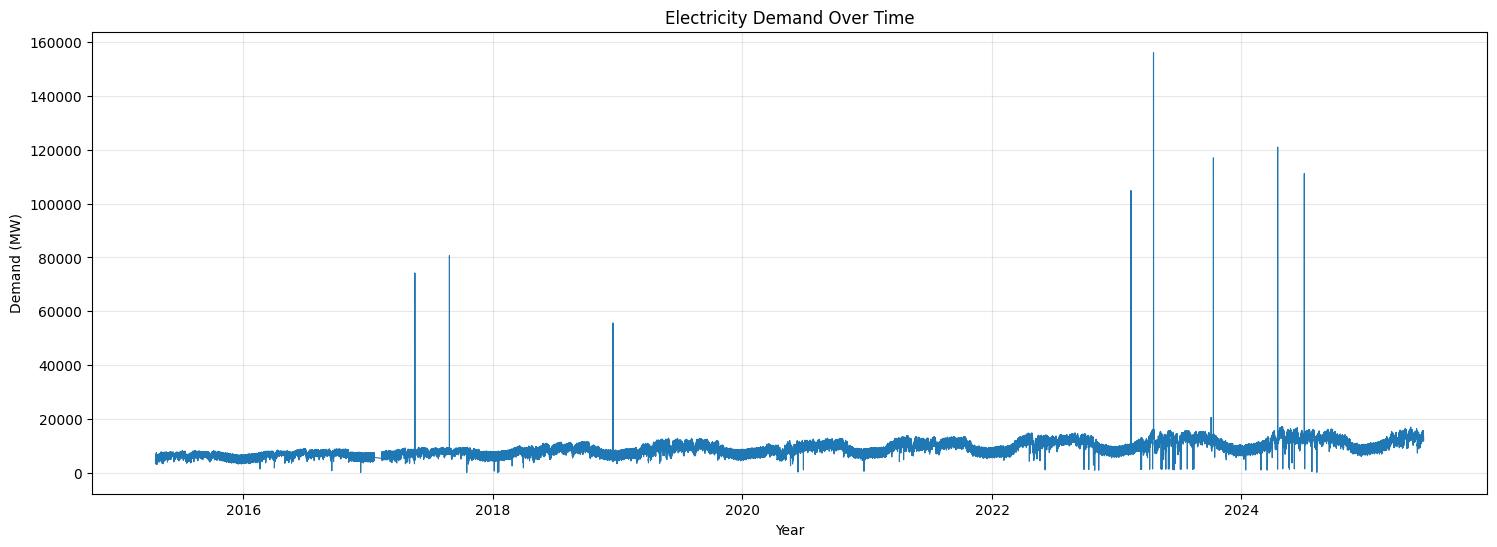

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))

plt.plot(dataset.index, dataset["demand_mw"], linewidth=0.8)

plt.title("Electricity Demand Over Time")
plt.xlabel("Year")
plt.ylabel("Demand (MW)")

plt.grid(alpha=0.3)

plt.show()

### Distribution of Electricity Demand

The histogram below illustrates the distribution of electricity demand values. It helps identify the overall spread of the data, detect skewness, and reveal whether extreme demand values occur frequently or represent potential outliers.

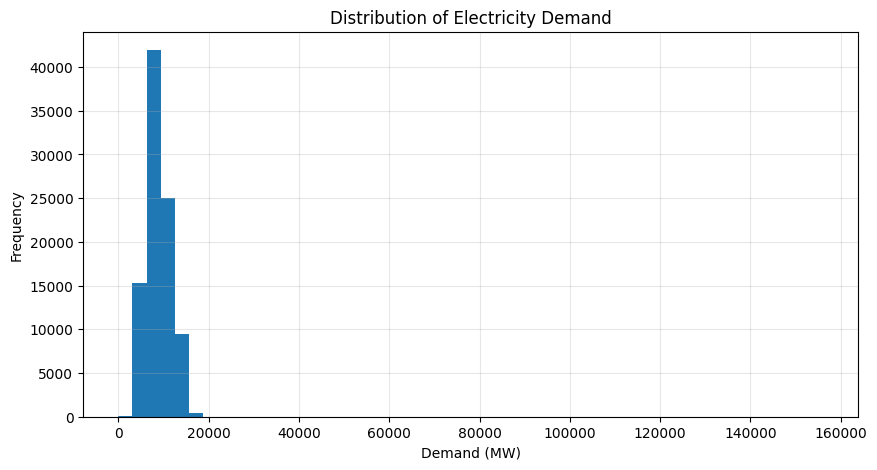

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(dataset["demand_mw"], bins=50)

plt.title("Distribution of Electricity Demand")
plt.xlabel("Demand (MW)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

### Boxplot of Electricity Demand

The boxplot summarizes the distribution of electricity demand and highlights potential outliers. Unlike the histogram, it provides a statistical view based on quartiles and the interquartile range (IQR), making it easier to identify unusually high or low observations.

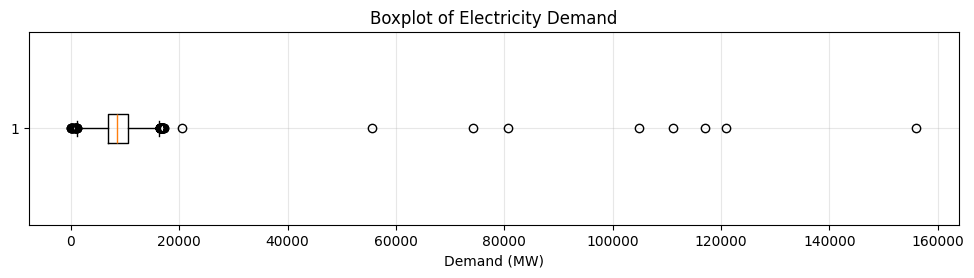

In [ ]:
plt.figure(figsize=(12,2.5))

plt.boxplot(dataset["demand_mw"], vert=False)

plt.title("Boxplot of Electricity Demand")
plt.xlabel("Demand (MW)")

plt.grid(alpha=0.3)

plt.show()

### Relationship Between Electricity Generation and Demand

The scatter plot below examines the relationship between electricity generation and electricity demand. A strong positive relationship would indicate that generation is an important predictor of electricity demand and should be retained as an input feature for forecasting models.

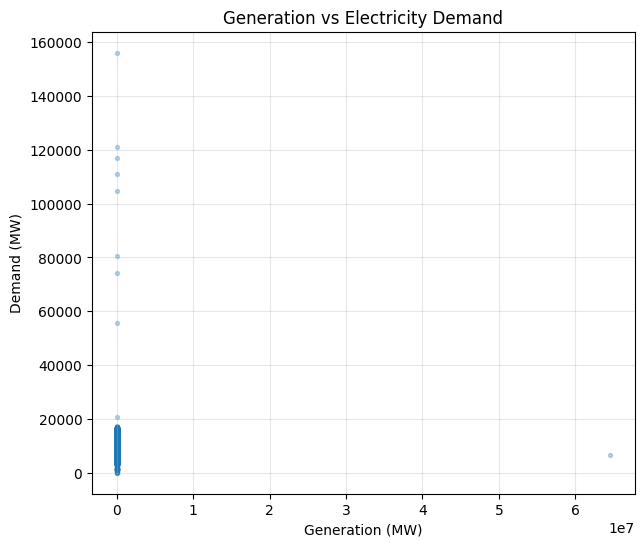

In [ ]:
plt.figure(figsize=(7,6))

plt.scatter(
    dataset["generation_mw"],
    dataset["demand_mw"],
    alpha=0.3,
    s=8
)

plt.title("Generation vs Electricity Demand")
plt.xlabel("Generation (MW)")
plt.ylabel("Demand (MW)")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Top 10 highest generation values

dataset.nlargest(10, "generation_mw")[
    ["generation_mw", "demand_mw", "load_shedding"]
]

,generation_mw,demand_mw,load_shedding
datetime,,,
2023-01-15 03:59:59,64526500.0,6452,0
2025-05-10 20:00:00,16603.0,17000,379
2024-04-30 20:00:00,16477.0,17000,499
2025-05-10 21:59:59,16373.0,16750,360
2025-05-10 21:00:00,16368.0,16700,317
2025-04-24 18:30:00,16364.0,16510,139
2025-05-10 23:00:00,16363.0,16690,312
2024-04-30 18:59:59,16245.0,16850,578
2024-04-22 20:00:00,16233.0,16700,446


### Removal of an Impossible Generation Value

During exploratory data analysis, one observation contained a generation value of **64,526,500 MW**, while all remaining observations were below approximately **17,000 MW**.
 Since the value was physically implausible and inconsistent with the corresponding electricity demand, the observation was treated as a recording error and removed before further analysis.

In [ ]:
# Remove impossible generation value (>100,000 MW)

print("Rows before:", len(dataset))

dataset = dataset[dataset["generation_mw"] < 100000]

print("Rows after :", len(dataset))

Rows before: 92218
Rows after : 92217


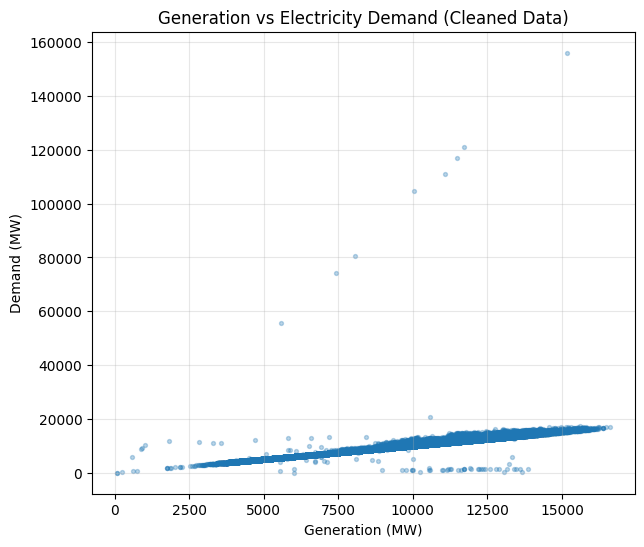

In [ ]:
plt.figure(figsize=(7,6))

plt.scatter(
    dataset["generation_mw"],
    dataset["demand_mw"],
    alpha=0.3,
    s=8
)

plt.title("Generation vs Electricity Demand (Cleaned Data)")
plt.xlabel("Generation (MW)")
plt.ylabel("Demand (MW)")

plt.grid(alpha=0.3)

plt.show()

In [ ]:
dataset.nlargest(10, "demand_mw")[
    ["generation_mw","demand_mw","load_shedding"]
]

,generation_mw,demand_mw,load_shedding
datetime,,,
2023-04-18 18:30:00,15172.0,156050,456
2024-04-16 06:59:59,11701.0,121000,381
2023-10-11 03:00:00,11468.0,117000,222
2024-07-03 05:00:00,11080.0,111140,57
2023-02-11 18:30:00,10052.0,104860,400
2017-08-26 15:00:00,8068.0,80689,65359
2017-05-17 12:00:00,7423.0,74223,60120
2018-12-18 08:00:00,5563.9,55639,45068
2023-10-04 09:00:00,10587.0,20587,0


In [ ]:
dataset.nsmallest(10, "demand_mw")[
    ["generation_mw","demand_mw","load_shedding"]
]

,generation_mw,demand_mw,load_shedding
datetime,,,
2018-01-14 11:00:00,6021.6,6,0
2017-10-16 09:00:00,73.0,73,0
2016-12-09 20:00:00,80.0,80,0
2024-08-08 23:00:00,13650.0,143,13800
2018-01-17 23:00:00,236.0,236,0
2020-06-12 02:00:00,10254.0,254,0
2024-07-25 09:59:59,13043.0,436,13500
2020-12-22 03:59:59,5556.0,556,0
2018-01-04 20:00:00,611.0,611,0


### Correlation Analysis Findings

The correlation matrix shows that **generation_mw** has the strongest positive correlation with **demand_mw** (0.94), indicating that electricity generation is the most important predictor of electricity demand.

Other moderately correlated variables include **coal (0.63)**, **india_adani (0.63)**, **gas (0.49)**, **india_bheramara_hvdc (0.45)** and **india_tripura (0.44)**. These variables are likely to contribute useful information to the forecasting model.

Renewable energy sources such as **solar (0.22)**, **wind (0.02)** and **hydro (0.07)** exhibit relatively weak correlations with electricity demand, suggesting that they have less direct influence on demand in this dataset.

Overall, no unexpected multicollinearity issues were observed that would prevent the use of these variables in machine learning models.

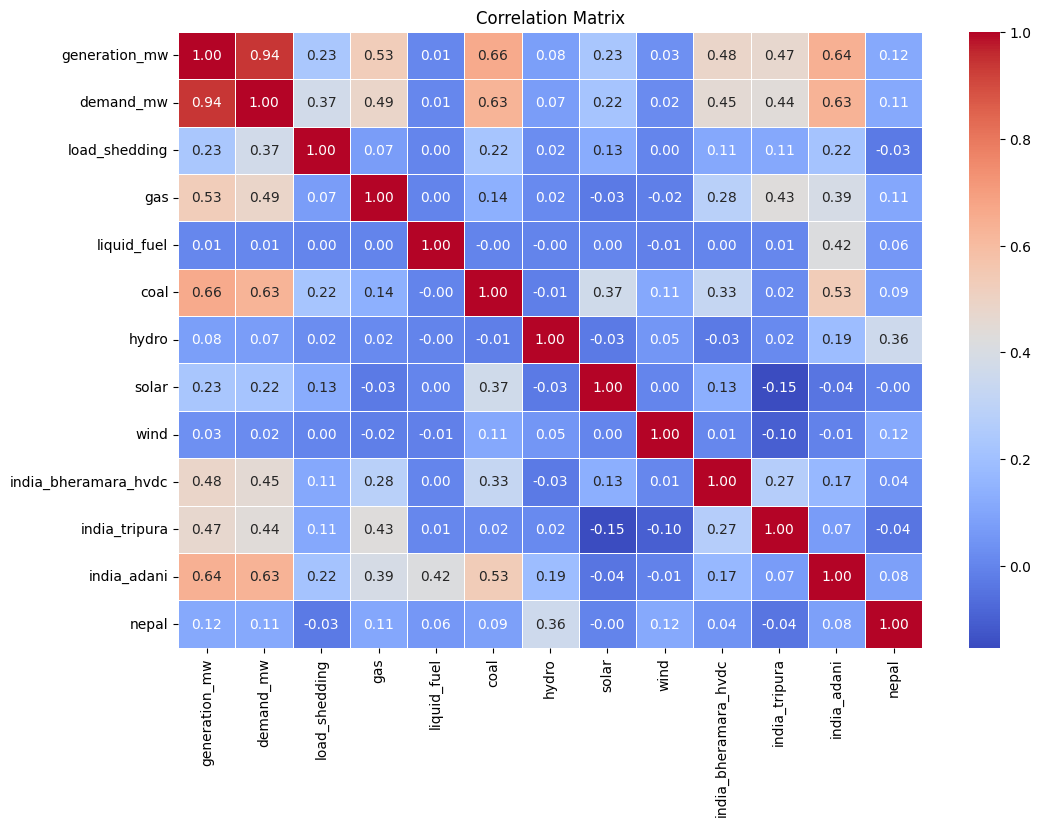

In [ ]:

plt.figure(figsize=(12, 8))

corr = dataset.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

### Availability of Power Generation Sources

Several variables contain a large number of missing values. Before deciding how to handle these missing values, it is important to determine whether they represent missing observations or whether the corresponding power sources were not yet operational during earlier years.

In [ ]:
# Check when each feature first contains a non-missing value

columns_to_check = [
    "solar",
    "wind",
    "india_adani",
    "nepal"
]

for col in columns_to_check:
    first_date = dataset[col].first_valid_index()
    print(f"{col:20s} --> {first_date}")

solar                --> 2017-09-20 06:00:00
wind                 --> 2023-06-01 06:00:00
india_adani          --> 2024-08-28 00:00:00
nepal                --> 2024-11-14 18:00:00



Based on the exploratory data analysis, the following preprocessing steps are applied before model development:

- Remove non-predictive columns.
- Replace structural missing values with zero.
- Verify that the dataset contains no remaining missing values.

In [ ]:
# Remove non-predictive text column
dataset = dataset.drop(columns=["remarks"])

# Fill structural missing values with zero
fill_columns = ["solar", "wind", "india_adani", "nepal"]

dataset[fill_columns] = dataset[fill_columns].fillna(0)

# Verify missing values
missing = dataset.isnull().sum()

print("Remaining missing values:")
print(missing[missing > 0])

Remaining missing values:
Series([], dtype: int64)


## Feature Engineering

Machine learning models cannot directly interpret datetime values. Therefore, several time-based features are extracted from the datetime index to capture temporal patterns such as daily, weekly and seasonal variations in electricity demand.

In [ ]:
# Create time-based features from the datetime index

dataset["year"] = dataset.index.year
dataset["month"] = dataset.index.month
dataset["day"] = dataset.index.day
dataset["hour"] = dataset.index.hour
dataset["day_of_week"] = dataset.index.dayofweek

# Weekend indicator (Saturday = 5, Sunday = 6)
dataset["is_weekend"] = dataset["day_of_week"].isin([5, 6]).astype(int)

# Preview the new features
dataset[
    ["year", "month", "day", "hour", "day_of_week", "is_weekend"]
].head()

,year,month,day,hour,day_of_week,is_weekend
datetime,,,,,,
2015-04-19 00:00:00,2015,4,19,0,6,1
2015-04-19 00:59:59,2015,4,19,0,6,1
2015-04-19 02:00:00,2015,4,19,2,6,1
2015-04-19 03:00:00,2015,4,19,3,6,1
2015-04-19 03:59:59,2015,4,19,3,6,1


In [ ]:
dataset.head()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,year,month,day,hour,day_of_week,is_weekend
datetime,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,2015,4,19,0,6,1
2015-04-19 00:59:59,3612.0,3612,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,2015,4,19,0,6,1
2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,2015,4,19,2,6,1
2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,2015,4,19,3,6,1
2015-04-19 03:59:59,3641.0,3641,0,0,0,0,0,0.0,0.0,0,0,0.0,0.0,2015,4,19,3,6,1


In [ ]:
# Check the distribution of time intervals for lag

time_diff = dataset.index.to_series().diff()

print(time_diff.value_counts().head(15))

datetime
0 days 01:00:01    29279
0 days 01:00:00    28739
0 days 00:59:59    25629
0 days 00:29:59     4164
0 days 00:30:00     3649
0 days 00:30:01      523
0 days 02:00:01       65
0 days 01:59:59       62
0 days 02:00:00       52
0 days 03:00:00       11
0 days 01:30:00        8
0 days 06:59:59        4
0 days 12:00:00        4
0 days 09:00:00        4
0 days 10:59:59        4
Name: count, dtype: int64


### Creating Lag Features

Electricity demand is highly dependent on previous demand levels. To capture temporal dependencies, three time-based features are created:

- Demand from the previous observation (`demand_lag_1`)
- Demand from approximately the previous day (`demand_lag_24`)
- Rolling average demand over the previous 24 observations (`rolling_mean_24`)

These features provide historical context while keeping the forecasting model simple and interpretable.

In [ ]:
# Create lag features

dataset["demand_lag_1"] = dataset["demand_mw"].shift(1)
dataset["demand_lag_24"] = dataset["demand_mw"].shift(24)

# Create rolling mean feature
dataset["rolling_mean_24"] = (
    dataset["demand_mw"]
    .rolling(window=24)
    .mean()
)

# Check missing values introduced by lagging
print(dataset[
    ["demand_lag_1", "demand_lag_24", "rolling_mean_24"]
].isnull().sum())

demand_lag_1        1
demand_lag_24      24
rolling_mean_24    23
dtype: int64


Removing missing rows

In [ ]:
dataset = dataset.dropna()

Data Modelling Preparation

In [ ]:
# Features and target
X = dataset.drop(columns=["demand_mw"])
y = dataset["demand_mw"]

# 80% train, 20% test (chronological split)

split_index = int(len(dataset) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 73754
Testing samples : 18439


## Linear Regression
Linear Regression is used as the baseline model for electricity demand forecasting. Its performance will be compared with more advanced machine learning and deep learning models.

In [ ]:
# Train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mape = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100
r2 = r2_score(y_test, y_pred_lr)

# Display Results
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

# Store evaluation metrics for all models
results = []
results.append({
    "Model": "Linear Regression",
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape,
    "R2": r2
})

MAE  : 363.01
RMSE : 1545.74
MAPE : 5.16%
R²   : 0.6715


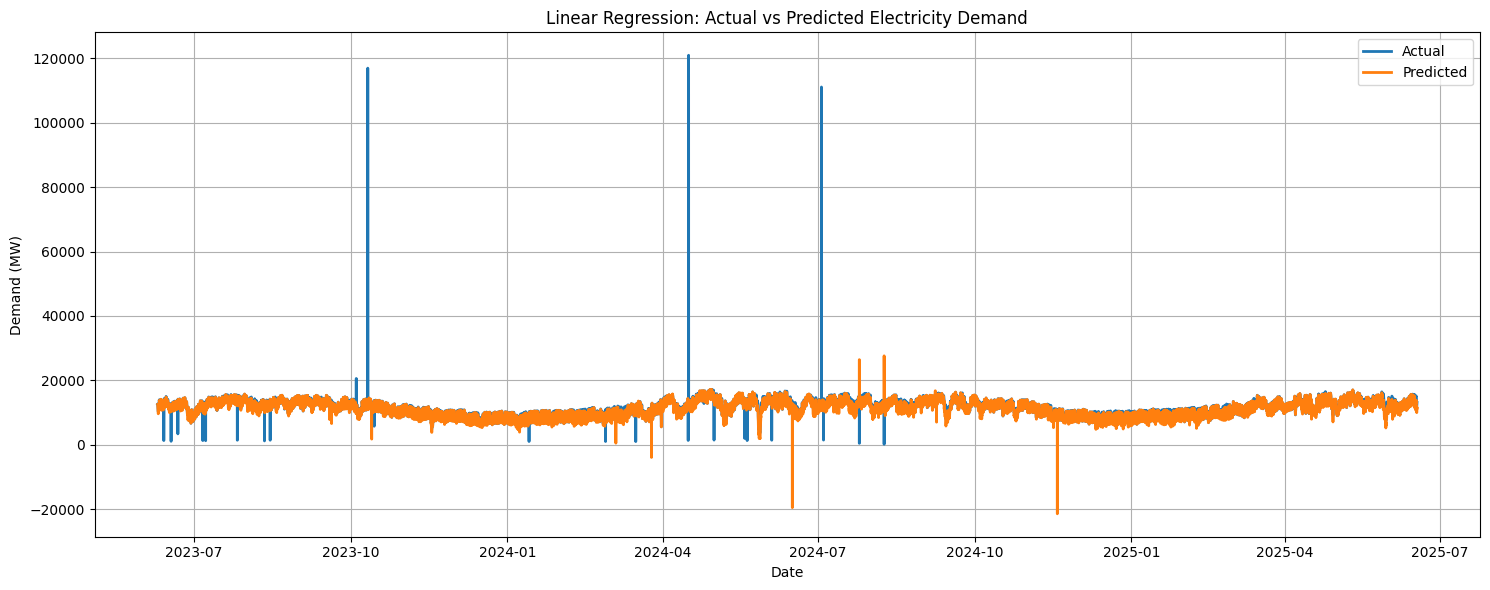

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.index,
    y_test,
    label="Actual",
    linewidth=2
)

plt.plot(
    y_test.index,
    y_pred_lr,
    label="Predicted",
    linewidth=2
)

plt.title("Linear Regression: Actual vs Predicted Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Random Forest Regression

Random Forest Regression is an ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is widely used for regression problems involving complex and non-linear relationships.

In [ ]:

# Train the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [ ]:
# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mape = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
r2 = r2_score(y_test, y_pred_rf)

# Display Results
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

# Store Results
results.append({
    "Model": "Random Forest",
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape,
    "R2": r2
})

MAE  : 318.73
RMSE : 1599.18
MAPE : 3.41%
R²   : 0.6483


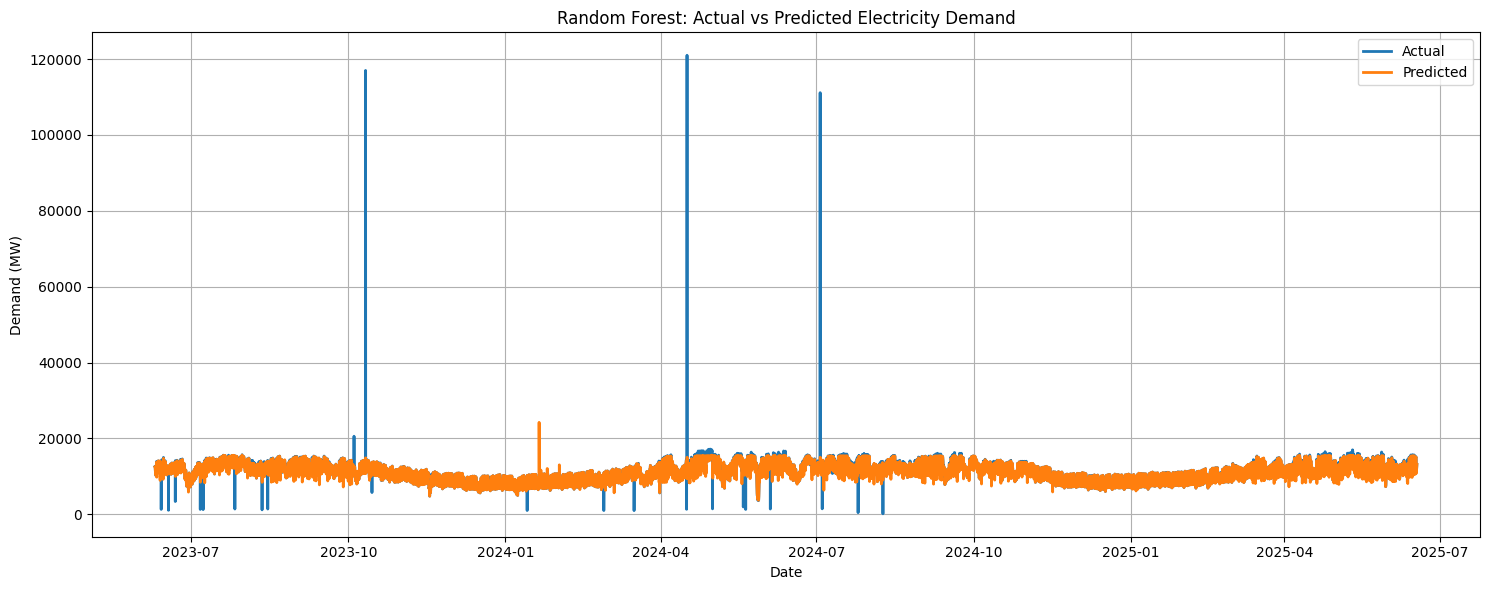

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.index,
    y_test,
    label="Actual",
    linewidth=2
)

plt.plot(
    y_test.index,
    y_pred_rf,
    label="Predicted",
    linewidth=2
)

plt.title("Random Forest: Actual vs Predicted Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## XGBoost Regression

Extreme Gradient Boosting (XGBoost) is an advanced ensemble learning algorithm that builds decision trees sequentially, where each new tree corrects the errors of the previous ones. It is known for its high predictive performance and efficiency on structured datasets.

In [ ]:

# Train the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mape = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100
r2 = r2_score(y_test, y_pred_xgb)

# Display Results
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

# Store Results
results.append({
    "Model": "XGBoost",
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape,
    "R2": r2
})

MAE  : 562.41
RMSE : 1704.87
MAPE : 5.89%
R²   : 0.6003


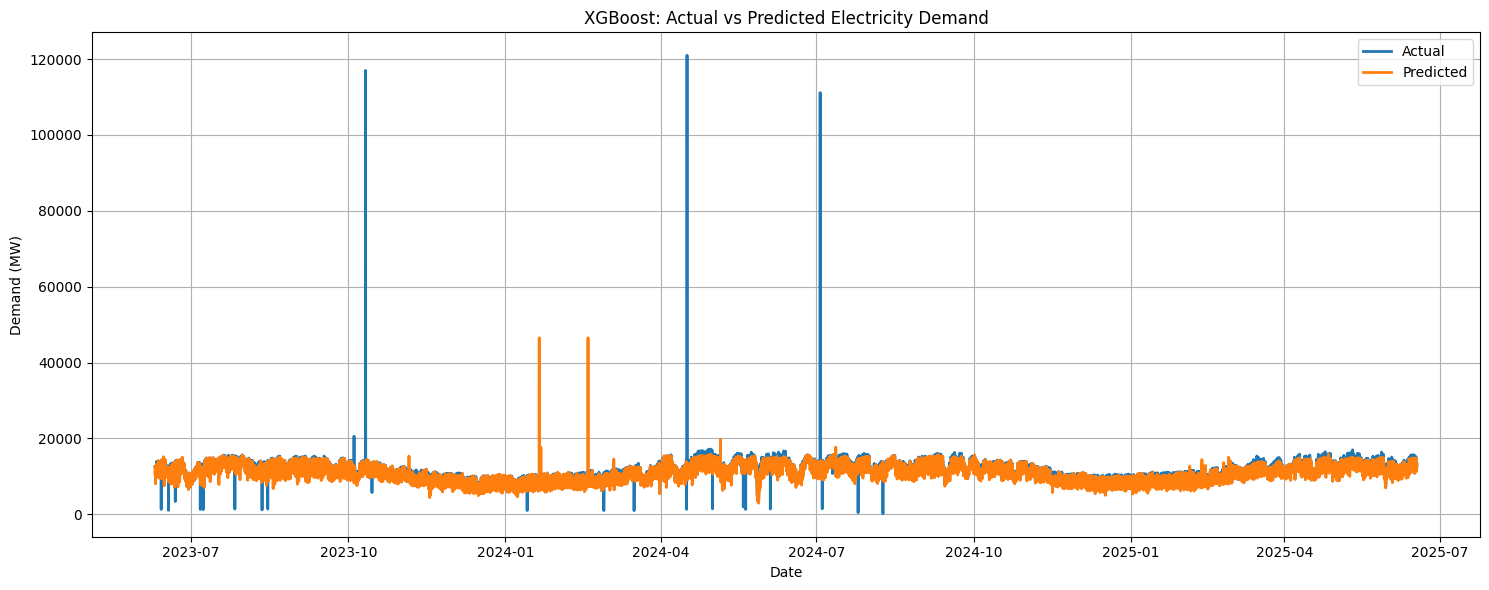

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test.index,
    y_test,
    label="Actual",
    linewidth=2
)

plt.plot(
    y_test.index,
    y_pred_xgb,
    label="Predicted",
    linewidth=2
)

plt.title("XGBoost: Actual vs Predicted Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Long Short-Term Memory (LSTM)

Long Short-Term Memory (LSTM) is a recurrent neural network architecture designed for sequential and time-series data. Unlike classical machine learning models, LSTM learns temporal dependencies directly from historical observations, making it suitable for electricity demand forecasting.

In [ ]:
# Scale features
feature_scaler = MinMaxScaler()
X_scaled = feature_scaler.fit_transform(X)

# Scale target
target_scaler = MinMaxScaler()
y_scaled = target_scaler.fit_transform(y.values.reshape(-1, 1))

In [ ]:
sequence_length = 24

X_lstm = []
y_lstm = []

for i in range(sequence_length, len(X_scaled)):
    X_lstm.append(X_scaled[i-sequence_length:i])
    y_lstm.append(y_scaled[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

print("X shape:", X_lstm.shape)
print("y shape:", y_lstm.shape)

X shape: (92169, 24, 21)
y shape: (92169, 1)


In [ ]:
split_index = int(len(X_lstm) * 0.8)

X_train_lstm = X_lstm[:split_index]
X_test_lstm = X_lstm[split_index:]

y_train_lstm = y_lstm[:split_index]
y_test_lstm = y_lstm[split_index:]

print("Training samples:", len(X_train_lstm))
print("Testing samples :", len(X_test_lstm))

Training samples: 73735
Testing samples : 18434


In [ ]:
# Build the LSTM model
lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,081 (86.25 KB)

 Trainable params: 22,081 (86.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 2.7227e-04 - val_loss: 1.0807e-04
Epoch 2/20
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 2.9653e-05 - val_loss: 1.0448e-04
Epoch 3/20
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 2.2399e-05 - val_loss: 1.0268e-04
Epoch 4/20
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 1.9142e-05 - val_loss: 1.0192e-04
Epoch 5/20
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - loss: 1.7689e-05 - val_loss: 1.0193e-04
Epoch 6/20
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - loss: 1.7210e-05 - val_loss: 1.0040e-04
Epoch 7/20
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 1.6610e-05 - val_loss: 1.0142e-04
Epoch 8/20
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 1.6019e-05 - val_loss: 1.0131e-04
Epoch 9/20
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 1.5782e-05 - val_loss: 1.0221e-04


In [ ]:
# Make predictions
y_pred_lstm = lstm_model.predict(X_test_lstm)

# Convert predictions back to original scale
y_pred_lstm = target_scaler.inverse_transform(y_pred_lstm)
y_test_actual = target_scaler.inverse_transform(y_test_lstm)

# Evaluation metrics
mae = mean_absolute_error(y_test_actual, y_pred_lstm)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm))
mape = np.mean(np.abs((y_test_actual - y_pred_lstm) / y_test_actual)) * 100
r2 = r2_score(y_test_actual, y_pred_lstm)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

# Store results
results.append({
    "Model": "LSTM",
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape,
    "R2": r2
})

577/577 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
MAE  : 484.95
RMSE : 1514.40
MAPE : 5.58%
R²   : 0.6847


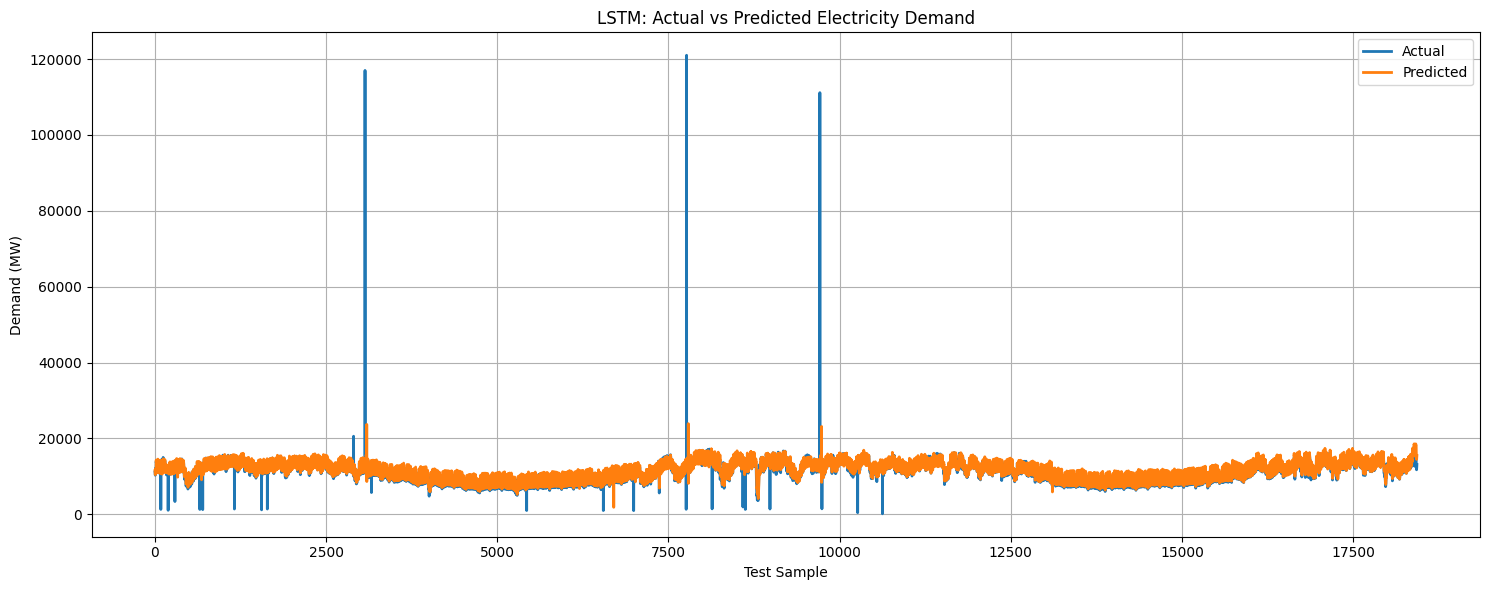

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test_actual,
    label="Actual",
    linewidth=2
)

plt.plot(
    y_pred_lstm,
    label="Predicted",
    linewidth=2
)

plt.title("LSTM: Actual vs Predicted Electricity Demand")
plt.xlabel("Test Sample")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

###Comparison Table

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.round({
    "MAE": 2,
    "RMSE": 2,
    "MAPE": 2,
    "R2": 4
})

results_df

,Model,MAE,RMSE,MAPE,R2
0,Linear Regression,363.01,1545.74,5.16,0.6715
1,Random Forest,318.73,1599.18,3.41,0.6483
2,XGBoost,562.41,1704.87,5.89,0.6003
3,LSTM,484.95,1514.40,5.58,0.6847


###Comparison Bar Charts

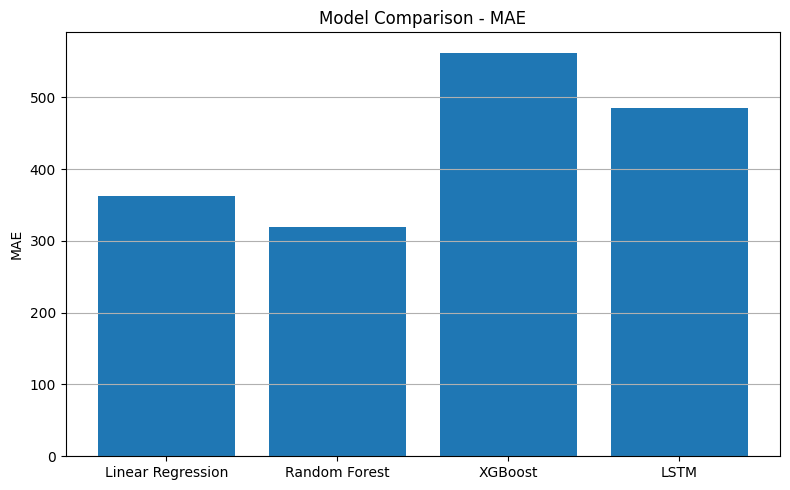

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["MAE"])

plt.title("Model Comparison - MAE")
plt.ylabel("MAE")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

## Model Performance Discussion

The performance of the four forecasting models was compared using MAE, RMSE, MAPE, and R². The results indicate that no single model achieved the best score across all evaluation metrics.

The **Random Forest** model achieved the lowest **MAE (318.73 MW)** and **MAPE (3.41%)**, indicating the smallest average prediction error and the highest overall prediction accuracy in percentage terms. This suggests that Random Forest provided the most consistent day-to-day forecasts.

The **LSTM** model achieved the lowest **RMSE (1514.40 MW)** and the highest **R² (0.6847)** after applying Early Stopping. These results indicate that the LSTM captured the overall trend and temporal dependencies in electricity demand more effectively than the other models while reducing larger prediction errors.

The **Linear Regression** model performed surprisingly well, producing results close to those of the LSTM despite its simplicity. This suggests that a substantial linear relationship exists between the selected features and electricity demand.

Among the evaluated models, **XGBoost** produced the weakest performance on this dataset, recording the highest prediction errors and the lowest coefficient of determination. This may be due to the default hyperparameter settings, as no hyperparameter tuning was performed in this project.

Overall, **Random Forest** is the preferred model when minimizing average prediction error is the primary objective, whereas **LSTM** provides the best overall fit to the data and is better suited for capturing temporal patterns in electricity demand forecasting.

###**Storing Results for Interactive Dashboard**

In [184]:
results_df.to_csv("results.csv", index=False)

In [185]:
lr_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lr
})

lr_results.to_csv("lr_predictions.csv", index=False)

In [186]:
rf_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf
})

rf_results.to_csv("rf_predictions.csv", index=False)

In [187]:
xgb_results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_xgb
})

xgb_results.to_csv("xgb_predictions.csv", index=False)

In [189]:
lstm_results = pd.DataFrame({
    "Actual": y_test_actual.flatten(),
    "Predicted": y_pred_lstm.flatten()
})

lstm_results.to_csv("lstm_predictions.csv", index=False)